# 01 Stock Data

Start here. Choose the research settings. Later modules load the saved settings and intermediate files from data/processed/current/. The default files are the repository’s existing inputs; their historical universe bias remains explicitly recorded.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [1]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'research_config.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter inside the Pairs_trading repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.project_io import OUTPUT_DIR, initialize, load_config, load_frame, save_frame, save_json


## 2. Settings

All model settings are chosen here. Each execution overwrites the current settings and input copies. After changing settings or inputs, rerun this notebook and the following modules in order.


In [2]:
from src.research_config import ResearchConfig
CONFIG = ResearchConfig()
PRICE_FILE = ROOT / 'data/processed/prices.parquet'
RATE_FILE = ROOT / 'data/processed/risk_free_rates.parquet'
BENCHMARK_FILE = ROOT / 'data/processed/systematic_risk/sp500_prices.parquet'
MEMBERSHIP_FILE = None  # Optional dated membership CSV paired with a full historical price panel.
ALLOW_LEGACY_UNIVERSE = True  # Acknowledge the included universe's known selection bias.
initialize(CONFIG, PRICE_FILE, RATE_FILE, BENCHMARK_FILE,
                                 membership=MEMBERSHIP_FILE, allow_legacy=ALLOW_LEGACY_UNIVERSE)
cfg = CONFIG
display(pd.Series(cfg.to_dict(), name='Research settings'))


Active notebook run: jupyter_v2_01
Module 01_stock | jupyter_v2_01


train_fraction                      0.7
max_missing_fraction               0.05
correlation_neighbors                10
cointegration_alpha                0.01
integration_alpha                  0.05
top_n                                40
initial_capital                100000.0
entry_z                             1.5
target_probability                  0.7
memory_window                        60
structural_horizon                  252
max_horizon_days                    126
n_paths                            5000
seed                                 42
ewma_lambda                        0.94
max_open_pairs                       10
premium_budget_fraction            0.05
max_hedge_error                     0.1
slippage_bps                       10.0
commission_per_contract            0.65
n_placebos                          100
bootstrap_replications            10000
bootstrap_blocks           [10, 20, 40]
hac_lags                              5
Name: Research settings, dtype: object

## 3. Load and split prices

The first 70% of sessions form the training sample. Missingness is evaluated only there; test-period prices are never used to select assets. No live download occurs.


In [3]:
from src.research_data import prepare_prices
prices = pd.read_parquet(OUTPUT_DIR / 'inputs/prices.parquet')
membership = pd.read_csv(OUTPUT_DIR / 'inputs/membership.csv') if (OUTPUT_DIR / 'inputs/membership.csv').exists() else None
train_prices, test_prices, availability = prepare_prices(prices, cfg, membership, ALLOW_LEGACY_UNIVERSE)
display(pd.DataFrame({'observations': [len(train_prices), len(test_prices)],
                      'start': [train_prices.index.min(), test_prices.index.min()],
                      'end': [train_prices.index.max(), test_prices.index.max()]}, index=['Formation', 'Out of sample']))
display(availability.head(10))


,observations,start,end
Formation,1759,2016-01-04,2022-12-27
Out of sample,755,2022-12-28,2025-12-31


,ticker,formation_missing_fraction,retained
0,A,0.0,True
1,AAPL,0.0,True
2,ABBV,0.0,True
3,ABT,0.0,True
4,ACGL,0.0,True
5,ACN,0.0,True
6,ADBE,0.0,True
7,ADI,0.0,True
8,ADM,0.0,True
9,ADP,0.0,True


## 4. Inspect and save

These new files go into this run’s folder. Old thesis output files are preserved.


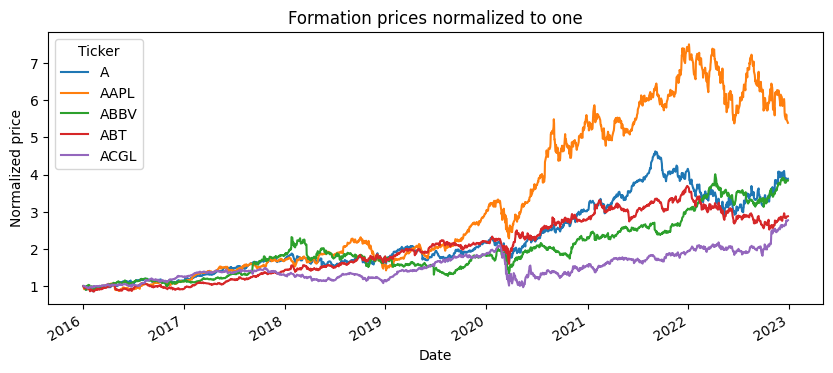

In [4]:
save_frame('train_prices', train_prices)
save_frame('test_prices', test_prices)
save_frame('availability', availability)
ax = (train_prices.iloc[:, :5] / train_prices.iloc[0, :5]).plot(figsize=(10, 4), title='Formation prices normalized to one')
ax.set_ylabel('Normalized price')
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.


In [5]:
print(f'Completed. Files saved in {OUTPUT_DIR}')


Completed 01_stock. Outputs saved in C:\Users\Iván\anaconda_projects\84fb5a87-072e-47a3-b69f-e9690ffef909\runs\jupyter_v2_01
